# DRUGI SEMINARSKI RAD 2025

KOLEGIJ: Napredna teorija algoritama i sustava

Datum predaje rada: 

Ime i prezime članova tima:

1. Leon Hojski
2. Karlo Bistrički
3. Marco Matijević
4. Matej Kiš

## Uvod

U ovom seminarskom radu analizirat će se mreža cestovnih pravaca između gradova. Koristit ćemo grafovsku reprezentaciju u obliku liste susjedstva i matrice susjedstva, a zatim ćemo analizirati najkraće putove, centralnost i druge metrike grafa.

### Klasa Graph

- Klasa Graph predstavlja strukturu usmjerenog ili neusmjerenog grafa. Sadrži rječnik u kojem su pohranjeni vrhovi grafa kao ključevi i njihovi susjedni vrhovi kao vrijednosti (liste). Kroz implementirane metode omogućeni su dohvat svih vrhova i bridova, kao i prikaz grafa. Uz to, podržana je iteracija kroz vrhove i ispis grafa u tekstualnom obliku.

- Na osnovi definirane strukture rječnika, omogućena je analiza grafa putem metoda poput pronalaženja puteva (jednog ili svih), izračuna stupnja vrhova, pronalaska izoliranih čvorova, gustoće grafa, dijametra i sekvence stupnjeva. Implementirane su i metode za mjerenje osnovnih metričkih svojstava grafa.

```py
class Graph(object):

    def __init__(self, graph_dict=None):
        """ inicijalizacija objekta:
            ako ništa nije predano inicijalizira se prazna struktura rječnika
        """
        if graph_dict == None:
            graph_dict = {}
        self._graph_dict = graph_dict

    def edges(self, vertice):
        """ vraća listu bridova za neki vrh"""
        return self._graph_dict[vertice]

    def all_vertices(self):
        """ vraća vrhove grafa """
        return set(self._graph_dict.keys())

    def all_edges(self):
        """ vraća bridove grafa """
        return self.__generate_edges()

    def add_vertex(self, vertex):
        """ dodavanje novog vrha """
        if vertex not in self._graph_dict:
            self._graph_dict[vertex] = []

    def add_edge(self, edge):
        """ dodavanje brida """
        edge = set(edge)
        vertex1, vertex2 = tuple(edge)
        for x, y in [(vertex1, vertex2), (vertex2, vertex1)]:
            if x in self._graph_dict:
                self._graph_dict[x].append(y)
            else:
                self._graph_dict[x] = [y]

    def __generate_edges(self):
        """ metoda za dobivanje liste bridova grafa """
        edges = []
        for vertex in self._graph_dict:
            for neighbour in self._graph_dict[vertex]:
                if {neighbour, vertex} not in edges:
                    edges.append({vertex, neighbour})
        return edges

    def __iter__(self):
        self._iter_obj = iter(self._graph_dict)
        return self._iter_obj

    def __next__(self):
        """ pomoćna metoda za iteriranje kroz vrhove """
        return next(self._iter_obj)

    def __str__(self):
        res = "vrhovi: "
        for k in self._graph_dict:
            res += str(k) + " "
        res += "\nrubovi: "
        for edge in self.__generate_edges():
            res += str(edge) + " "
        return res

    def find_path(self, start_vertex, end_vertex, path=None):
        """ pronalaženje puta između dva vrha """
        if path == None:
            path = []
        graph = self._graph_dict
        path = path + [start_vertex]
        if start_vertex == end_vertex:
            return path
        if start_vertex not in graph:
            return None
        for vertex in graph[start_vertex]:
            if vertex not in path:
                extended_path = self.find_path(vertex,
                                               end_vertex,
                                               path)
                if extended_path:
                    return extended_path
        return None

    def find_all_paths(self, start_vertex, end_vertex, path=[]):
        """ pronalaženje svih puteva između dva vrha """
        graph = self._graph_dict
        path = path + [start_vertex]
        if start_vertex == end_vertex:
            return [path]
        if start_vertex not in graph:
            return []
        paths = []
        for vertex in graph[start_vertex]:
            if vertex not in path:
                extended_paths = self.find_all_paths(vertex,
                                                     end_vertex,
                                                     path)
                for p in extended_paths:
                    paths.append(p)
        return paths

    def vertex_degree(self, vertex):
        """ vraća stupanj vrha """
        degree = len(self._graph_dict[vertex])
        if vertex in self._graph_dict[vertex]:
            degree += 1
        return degree

    def find_isolated_vertices(self):
        """ vraća listu izoliranih vrhova """
        graph = self._graph_dict
        isolated = []
        for vertex in graph:
            print(isolated, vertex)
            if not graph[vertex]:
                isolated += [vertex]
        return isolated

    def Delta(self):
        """ najveći stupanj između svih vrhova """
        max = 0
        for vertex in self._graph_dict:
            vertex_degree = self.vertex_degree(vertex)
            if vertex_degree > max:
                max = vertex_degree
        return max

    def degree_sequence(self):
        """ vraća sekvencu stupnjeva """
        seq = []
        for vertex in self._graph_dict:
            seq.append(self.vertex_degree(vertex))
        seq.sort(reverse=True)
        return tuple(seq)

    def density(self):
        """ izračun gustoće grafa """
        g = self._graph_dict
        V = len(g.keys())
        E = len(self.all_edges())
        return (2.0 * E) / (V * (V - 1))

    def diameter(self):
        """ izračun dijametra grafa"""

        v = tuple(self.all_vertices())
        pairs = [(v[i], v[j]) for i in range(len(v) - 1) for j in range(i + 1, len(v))]
        smallest_paths = []
        for (s, e) in pairs:
            paths = self.find_all_paths(s, e)
            smallest = sorted(paths, key=len)[0]
            smallest_paths.append(smallest)

        smallest_paths.sort(key=len)

        # longest path is at the end of list,
        # i.e. diameter corresponds to the length of this path
        diameter = len(smallest_paths[-1]) - 1
        return diameter
```

### Klasa Put

- Klasa Put predstavlja model podatka o putu između gradova. Sadrži informacije o odredištu, udaljenosti, prosječnoj brzini  (pb), opcionalnoj oznaci i trajanju putovanja. Također generira kratku oznaku (short) na temelju prva dva slova naziva odredišta.

- Implementirane su metode za prikaz pojedinog puta u čitljivom obliku (__str__) te za prikaz u listama i strukturama (__repr__), što omogućuje jednostavniji ispis i pregled prilikom iteracije ili ispisa više objekata.

```py
class Put:
    def __init__(self, odrediste, udaljenost, pb, oznaka=None, trajanje=None):
        self.odrediste = odrediste
        self.udaljenost = udaljenost
        self.pb = pb
        self.oznaka = oznaka
        self.trajanje = trajanje
        self.short = self.odrediste[0] + self.odrediste[1]
    def __str__(self):
        return f"{self.odrediste} ({self.udaljenost} km, {self.trajanje:.1f} min)"

    def __repr__(self):
        return self.odrediste

```

### Metoda za učitavanje cestovnih podataka iz Excela

- Funkcija `ucitaj_excel_u_segmente(file)` služi za učitavanje cestovne mreže iz Excel datoteke, pri čemu svaki redak predstavlja jedan pravac između dva grada. Iz svakog retka generiraju se dva objekta tipa Put, koji predstavljaju dvosmjerni odnos između polazišta i odredišta.

- Svi podaci se organiziraju u rječnik (ceste) gdje su ključevi nazivi gradova, a vrijednosti liste svih povezanih puteva. Time se dobiva struktura pogodna za daljnju obradu grafa.

```py
def ucitaj_excel_u_segmente(file):
    df = pd.read_excel(file)
    ceste = dict()
    for _, red in df.iterrows():

        if red['POLAZIŠTE'] not in ceste:
            ceste[red['POLAZIŠTE']] = []
        if red['ODREDIŠTE'] not in ceste:
            ceste[red['ODREDIŠTE']] = []


        segment1 = Put(
            odrediste=red['ODREDIŠTE'],
            oznaka=red['OZNAKA CESTE'],
            udaljenost=red['UDALJENOST km'],
            pb=red['PROSJEČNA BRZ km/h'],
            trajanje=red['TRAJANJE [min]']
        )
        segment2 = Put(
            odrediste=red['POLAZIŠTE'],
            oznaka=red['OZNAKA CESTE'],
            udaljenost=red['UDALJENOST km'],
            pb=red['PROSJEČNA BRZ km/h'],
            trajanje=red['TRAJANJE [min]']
        )
        ceste[red['POLAZIŠTE']].append(segment1)
        ceste[red['ODREDIŠTE']].append(segment2)
    return ceste


file = 'MREZA_CESTOVNIH_PRAVACA_CUSTOM.xlsx'
ceste = ucitaj_excel_u_segmente(file)
```

## Crtanje grafa

Za vizualizaciju cestovne mreže implementirana je funkcija draw_graph, koja koristi NetworkX i Matplotlib za crtanje usmjerenog grafa. Gradovi se prikazuju kao čvorovi, a putevi između njih kao bridovi, s mogućnošću prikaza udaljenosti ili trajanja putovanja kao oznaka na bridovima. Prilikom crtanja koristi se spring_layout za automatsko pozicioniranje čvorova, a oznake se dinamički prilagođavaju ovisno o odabranom kriteriju (udaljenost ili trajanje). Funkcija omogućuje jednostavnu i preglednu vizualnu analizu prometne povezanosti, ali se ne oslanja na keširanje ni spremanje slike grafa – svaki poziv funkcije iznova generira i prikazuje graf na temelju danih podataka.

```py
def draw_graph(g, otezanost='udaljenost'):
    G = nx.DiGraph()  # Koristimo DiGraph jer su putevi usmjereni (možete koristiti nx.Graph() za neusmjereni graf)

    # Dodavanje čvorova i bridova
    for grad, putevi in g.items():
        for put in putevi:
            # Dodajemo brid od 'grad' do 'put.odrediste' s atributima
            G.add_edge(grad, put.odrediste,
                       udaljenost=put.udaljenost,
                       oznaka=put.oznaka,
                       trajanje=put.trajanje)

    # Crtanje grafa
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G)  # Postavljanje pozicija čvorova

    # Crtanje čvorova i bridova
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, arrows=True)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Dodavanje oznaka na bridove (možete koristiti bilo koji atribut)
    #edge_labels = nx.get_edge_attributes(G, 'oznaka')
    if otezanost == 'udaljenost':
        edge_labels = {(u, v): f"{d['udaljenost']} km" for u, v, d in G.edges(data=True)}
    if otezanost == 'trajanje':
        edge_labels = {(u, v): f"{d['trajanje']} min" for u, v, d in G.edges(data=True)}
    #edge_labels = {(u, v): f"{d['oznaka']}\n{d['udaljenost']} km" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.title("Gradovi i putevi u Hrvatskoj")
    plt.axis('off')  # Isključujemo osi
    plt.tight_layout()
    plt.show()
```

## Generiranje matrice

Funkcija ispisMatrice koristi NetworkX i Pandas biblioteke za generiranje i spremanje matrica susjedstva na temelju cestovne mreže. Na temelju ulazne strukture podataka prvo se kreira usmjereni graf s atributima bridova (udaljenost, trajanje, oznaka), a zatim se pomoću funkcije to_pandas_adjacency generiraju dvije matrice susjedstva – jedna za udaljenost (u kilometrima), druga za trajanje (u minutama). Obje matrice se spremaju u CSV datoteke (matrica_susjedstva_udaljenost.csv i matrica_susjedstva_trajanje.csv) kako bi bile dostupne za daljnju analizu bez potrebe za ponovnim izračunavanjem. Na kraju funkcija prikazuje pregled prvih redaka matrice udaljenosti kao primjer strukture podataka.

```py
def ispisMatrice(g):
    # Kreiranje grafa
    G = nx.DiGraph()

    # Dodavanje bridova s atributima
    for grad, putevi in g.items():
        for put in putevi:
            G.add_edge(grad, put.odrediste,
                       udaljenost=put.udaljenost,
                       trajanje=put.trajanje,
                       oznaka=put.oznaka)

    # Generiranje matrice susjedstva (udaljenost)
    gradovi = sorted(G.nodes())
    matrica_susjedstva = nx.to_pandas_adjacency(G, weight='udaljenost', dtype=int)

    # Spremanje u CSV
    matrica_susjedstva.to_csv('matrica_susjedstva_udaljenost.csv')
    print("Matrica susjedstva (udaljenost) spremljena u 'matrica_susjedstva_udaljenost.csv'")

    # Opcionalno: Matrica susjedstva za trajanje
    matrica_trajanje = nx.to_pandas_adjacency(G, weight='trajanje', dtype=int)
    matrica_trajanje.to_csv('matrica_susjedstva_trajanje.csv')
    print("Matrica susjedstva (trajanje) spremljena u 'matrica_susjedstva_trajanje.csv'")

    # Prikaz prvih redova matrice
    print("\nPrimjer matrice susjedstva (udaljenost):")
    print(matrica_susjedstva.head())
```

## Najkraći put (Dijkstra algoritam)

Funkcija `najkraci_put` koristi Dijkstrin algoritam iz biblioteke NetworkX za pronalaženje najkraćeg puta između dva grada na temelju zadanog kriterija – bilo prema udaljenosti (u kilometrima) ili trajanju (u minutama). Na temelju strukture ceste najprije se kreira usmjereni graf u kojem su bridovi označeni relevantnim atributima (udaljenost, trajanje, oznaka). Funkcija zatim računa najkraći put i njegovu ukupnu vrijednost pomoću ugrađenih funkcija `shortest_path` i `shortest_path_length`. Vraća se tuple koji sadrži ukupnu vrijednost i redoslijed gradova na putu. Ako između dva grada ne postoji put, funkcija vraća `(None, None)`. Implementacija je fleksibilna i podržava promjenu kriterija optimizacije bez potrebe za izmjenom strukture podataka.

```py
def najkraci_put(ceste, pocetak, kraj, kriterij='udaljenost'):
    # Kreiranje usmjerenog grafa
    G = nx.DiGraph()

    # Dodavanje bridova s atributima
    for grad, putevi in ceste.items():
        for put in putevi:
            G.add_edge(grad, put.odrediste,
                       udaljenost=put.udaljenost,
                       trajanje=put.trajanje,
                       oznaka=put.oznaka)
    """
    Pronalazi najkraći put između dva grada prema odabranom kriteriju.

    Parametri:
        G (nx.Graph): Graf
        pocetak (str): Početni grad
        kraj (str): Odredišni grad
        kriterij (str): 'udaljenost' ili 'trajanje'

    Vraća:
        tuple: (ukupna vrijednost, lista čvorova)
    """
    try:
        if kriterij == 'udaljenost':
            put = nx.shortest_path(G, source=pocetak, target=kraj, weight='udaljenost')
            vrijednost = nx.shortest_path_length(G, source=pocetak, target=kraj, weight='udaljenost')
        elif kriterij == 'trajanje':
            put = nx.shortest_path(G, source=pocetak, target=kraj, weight='trajanje')
            vrijednost = nx.shortest_path_length(G, source=pocetak, target=kraj, weight='trajanje')
        else:
            raise ValueError("Kriterij mora biti 'udaljenost' ili 'trajanje'")

        return (vrijednost, put)
    except nx.NetworkXNoPath:
        return (None, None)
```

## Netežinski graf – dijametar, gustoća, stupnjevi

Za analizu osnovnih strukturnih svojstava mreže konstruiran je netežinski graf tako da se prilikom dodavanja bridova zanemaruju težine (npr. udaljenost ili trajanje). Na temelju takvog grafa izračunavaju se ključne metrike: dijametar (najveća udaljenost između bilo koja dva čvora izražena brojem bridova), gustoća grafa (omjer stvarnog broja bridova i maksimalnog mogućeg), te stupanj vrhova (broj bridova povezanih s pojedinim čvorom). Dijametar pruža uvid u “rastegnutost” mreže, gustoća u razinu povezanosti, dok stupnjevi otkrivaju koji su čvorovi najpovezaniji. Računanje ovih metrika omogućeno je putem ugrađenih metoda unutar klase Graph, a služi kao temelj za dublju topološku i funkcionalnu analizu cestovne mreže.

## Dijametar

```py
def diameter(self):
        """ izračun dijametra grafa"""

        v = tuple(self.all_vertices())
        pairs = [(v[i], v[j]) for i in range(len(v) - 1) for j in range(i + 1, len(v))]
        smallest_paths = []
        for (s, e) in pairs:
            paths = self.find_all_paths(s, e)
            smallest = sorted(paths, key=len)[0]
            smallest_paths.append(smallest)

        smallest_paths.sort(key=len)

        # longest path is at the end of list,
        # i.e. diameter corresponds to the length of this path
        diameter = len(smallest_paths[-1]) - 1
        return diameter
```

## Gustoća

```py
def density(self):
        """ izračun gustoće grafa """
        g = self._graph_dict
        V = len(g.keys())
        E = len(self.all_edges())
        return (2.0 * E) / (V * (V - 1))
```

## Stupnjevi

```py
def degree_sequence(self):
        """ vraća sekvencu stupnjeva """
        seq = []
        for vertex in self._graph_dict:
            seq.append(self.vertex_degree(vertex))
        seq.sort(reverse=True)
        return tuple(seq)
```

## Centralnost čvorova

Za analizu važnosti pojedinih čvorova u mreži izračunate su četiri standardne mjere centralnosti koristeći NetworkX biblioteku:

- Stupnjeva centralnost (Degree centrality) mjeri broj neposrednih veza koje čvor ima; veća vrijednost ukazuje na lokalno važan čvor s mnogo izravnih poveznica.

- Blizinska centralnost (Closeness centrality) odražava koliko je čvor blizu svim ostalim čvorovima u mreži – čvorovi s visokom blizinom mogu brzo komunicirati s ostalima.

- Međupoloženost (Betweenness centrality) mjeri koliko često se čvor pojavljuje na najkraćim putevima između ostalih čvorova; visoke vrijednosti ukazuju na čvorove koji djeluju kao "posrednici" u prometnoj mreži.

- Svojstvena centralnost (Eigenvector centrality) procjenjuje važnost čvora ne samo po broju veza, već i po važnosti čvorova s kojima je povezan.

Sve mjere izračunate su nad netežinskim grafom, a rezultati omogućuju identifikaciju ključnih prometnih čvorišta i analiza uloge svakog grada u mreži.

# Stupnjeva

```py
def degree_centrality(graph):
    """
    Calculate degree centrality for each node.
    Degree centrality is simply the number of connections a node has.
    """
    centrality = {}
    max_degree = len(graph) - 1  # maximum possible degree
    for node in graph:
        degree = len(graph[node])
        centrality[node] = degree / max_degree if max_degree > 0 else 0
    return centrality
```

# Blizinska

```py
def closeness_centrality(graph):
    """
    Calculate closeness centrality for each node.
    Closeness centrality is the inverse of the average shortest path distance to all other nodes.
    """
    centrality = {}
    nodes = list(graph.keys())
    n = len(nodes)

    for node in nodes:
        # BFS to calculate shortest paths to all other nodes
        distances = {n: -1 for n in nodes}
        distances[node] = 0
        queue = deque([node])

        while queue:
            current = queue.popleft()
            for neighbor in graph[current]:
                if distances[neighbor] == -1:  # not visited yet
                    distances[neighbor] = distances[current] + 1
                    queue.append(neighbor)

        total_distance = sum(distances.values())
        if total_distance > 0:
            centrality[node] = (n - 1) / total_distance
        else:
            centrality[node] = 0

    return centrality
```

# Međupoloženost

```py
def betweenness_centrality(graph):
    """
    Calculate betweenness centrality for each node.
    Betweenness centrality measures how often a node appears on shortest paths between other nodes.
    """
    nodes = list(graph.keys())
    centrality = {node: 0 for node in nodes}

    for s in nodes:
        # BFS from source node s
        pred = {node: [] for node in nodes}  # predecessors
        dist = {node: -1 for node in nodes}  # distances
        sigma = {node: 0 for node in nodes}  # number of shortest paths
        sigma[s] = 1
        dist[s] = 0
        queue = deque([s])
        stack = []

        while queue:
            v = queue.popleft()
            stack.append(v)
            for w in graph[v]:
                if dist[w] == -1:  # first time seeing w
                    dist[w] = dist[v] + 1
                    queue.append(w)
                if dist[w] == dist[v] + 1:  # shortest path to w via v
                    sigma[w] += sigma[v]
                    pred[w].append(v)

        delta = {node: 0 for node in nodes}
        while stack:
            w = stack.pop()
            for v in pred[w]:
                delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
            if w != s:
                centrality[w] += delta[w]

    # Normalize the centrality values
    n = len(nodes)
    if n > 2:
        scale = 1 / ((n - 1) * (n - 2))
        centrality = {k: v * scale for k, v in centrality.items()}

    return centrality
```

# Svojstvena

```py
def eigenvector_centrality(graph, max_iter=100, tol=1.0e-6):
    """
    Calculate eigenvector centrality for each node.
    Eigenvector centrality measures a node's importance based on the importance of its neighbors.
    """
    nodes = list(graph.keys())
    n = len(nodes)
    node_index = {node: i for i, node in enumerate(nodes)}

    # Create adjacency matrix
    adj_matrix = np.zeros((n, n))
    for node in nodes:
        for neighbor in graph[node]:
            adj_matrix[node_index[node]][node_index[neighbor]] = 1

    # Power iteration
    x = np.ones(n) / n  # initial vector
    for _ in range(max_iter):
        x_new = adj_matrix @ x
        x_new = x_new / np.linalg.norm(x_new, 2)
        if np.linalg.norm(x_new - x, 2) < tol:
            break
        x = x_new

    centrality = {nodes[i]: x[i] for i in range(n)}
    return centrality
```

## Prikaz rezultata

Za točan kod pogledati sekciju [Implementacija](#implementacija).

1. Prikazati listu susjedstva i matricu susjedstva cestovne mreže za oba slučaja
otežanosti pravaca. Napomena: umjesto naziva gradova čvorovi se mogu
označiti skraćenicama (ZG, KT, itd.) radi jednostavnijeg crtanja te je potrebno
uzeti u obzir da se radi o neusmjerenom grafu.

    - Za prikaz međusobne povezanosti gradova korištena je lista susjedstva koja sadrži gradove i njihove veze (puteve) s pripadajućim udaljenostima i trajanjem putovanja, npr. Zagreb je povezan s Karlovcem (53.3 km), Siskom (57.5 km), Varaždinom (87.0 km) i dr. Na temelju tih podataka generirane su dvije matrice susjedstva - jedna za udaljenosti, a druga za trajanje putovanja - koje prikazuju povezanost svih gradova u obliku tablice i spremljene su u CSV formatu radi lakše analize. U obradi je korišten Pythonov modul NetworkX, a ulazni podaci su učitani iz Excel datoteke.

2. Vizualizirati grafove za oba slučaja otežanosti. Može se koristiti NetworkX
modul ili drugi proizvoljan pristup. Primjerice, Python biblioteke pydot i
pygraphviz generiraju slike u PNG formatu.

    - Vizualizacija podataka napravljena je putem dva usmjerena grafa - prvi prikazuje udaljenosti između gradova, a drugi trajanje putovanja. U oba grafa gradovi su predstavljeni kao čvorovi, dok su putevi prikazani kao bridovi označeni pripadajućim vrijednostima (udaljenost u kilometrima ili trajanje u minutama). Grafovi su izrađeni pomoću NetworkX modula, pri čemu su pozicije čvorova određene algoritmom spring_layout, a za prikaz je korišten matplotlib.

3. Implementirati funkcionalnost koja će za primjere proizvoljno zadanih polazišta
i odredišta izračunati najkraće putove između njih (dokumentirati najmanje četiri
proizvoljna primjera), i s obzirom na udaljenost u [km] i s obzirom na trajanje
putovanja u [min]. U oba slučaja pored vrijednosti najkraćeg puta dati i redoslijed
svih čvorova na tom putu. Može se koristiti postojeći Python kôd za Dijkstra
algoritam, dati rješenje u bilo kojem drugom jeziku ili uporabom NetworkX
biblioteke.

    - Za pronalaženje najkraćih puteva između gradova korišten je Dijkstra algoritam iz NetworkX modula, koji uzima u obzir težine bridova (bilo udaljenost u kilometrima ili trajanje u minutama) i vraća ukupnu vrijednost te redoslijed čvorova. Na primjer, najkraći put između Zagreba i Splita prema udaljenosti iznosi 426,3 km, a prema trajanju 311,9 minuta, pri čemu je redoslijed gradova: Zagreb → Karlovac → Gospić → Split.

4. Izgraditi netežinsku inačicu grafa ove cestovne mreže kao primjera povezanosti
vrhova te temeljem toga:
    -  a. Odrediti dijametar grafa, gustoću grafa i stupnjeve svih čvorova.
    -  b. Odrediti mjere centralnosti (one četiri koje su spomenute u materijalima
s predavanja) svih vrhova grafa. 

    - Analiza strukture grafa provedena je na netežinskom grafu, generiranom zanemarivanjem težina bridova, a za izračun mjera korištene su ugrađene funkcije NetworkX modula. Dijametar grafa, odnosno najveći broj bridova između bilo koja dva čvora, iznosi 0.05, što ukazuje na relativno rijedak graf s malim brojem stvarnih bridova u odnosu na maksimalan mogući broj. Stupnjevi čvorova variraju, pri čemu Zagreb ima najveći stupanj jer je povezan s najviše gradova. U analizi centralnosti, Zagreb ima najveću stupanjsku centralnost, kao i visoku međupoloženost i svojstvenu centralnost jer se često pojavljuje na najkraćim putevima i povezan je s drugim važnim čvorovima.

## 8. Zaključak

Analiza cestovne mreže između gradova pomoću grafova pokazala je koliko su algoritmi poput Dijkstrinog korisni za pronalaženje najkraćih ruta, bilo da gledamo udaljenost ili trajanje putovanja. Korištenjem klasa Graph i Put, zajedno s metodama za učitavanje podataka iz Excela, crtanje grafa i generiranje matrica susjedstva, dobili smo jasniji uvid u to kako su gradovi povezani i koliko je mreža kompleksna.

Dijkstra algoritam se pokazao jako praktičnim - brzo i efikasno pronađe najbolji put između bilo koja dva grada, što bi se moglo primijeniti i u stvarnim aplikacijama poput navigacije ili planiranja prometa. Analizom netežinskog grafa mogli smo izračunati metrike kao što su dijametar, gustoća i stupnjevi čvorova, što nam govori koliko je cijela mreža "rastegnuta" i koji su gradovi najpovezaniji.

Mjere centralnosti (stupnjeva, blizinska, međupoloženost i svojstvena centralnost) posebno su bile korisne za prepoznavanje najvažnijih gradova u mreži - Zagreb je, očekivano, iskočio kao centralno čvorište. Vizualizacija grafa pomoću NetworkX-a omogućila je jednostavan i pregledan prikaz mreže, dok su matrice susjedstva dale konkretnu numeričku sliku odnosa među gradovima.

Sve u svemu, ova analiza pokazala je kako teorija grafova i algoritmi nisu samo apstraktne ideje, već mogu imati stvarnu primjenu u svakodnevnim problemima, kao što je promet. Osim toga, vidi se koliko je koristan spoj programiranja, matematike i stvarnog svijeta kada pokušavamo riješiti zadatke poput optimizacije prometne infrastrukture.

## Implementacija

### Inicijalizacijski kod

Ovdje se provedi učitavanje podataka iz datoteke `MREZA_CESTOVNIH_PRAVACA_CUSTOM.xlsx` i stvaranje grafa.

In [4]:
from Put import *
import pandas as pd
from drawGraph import *
from najkraciPut import *
from graf import *
from Centralnosti import *
from Matrica import *


def ucitaj_excel_u_segmente(file):
    df = pd.read_excel(file)
    ceste = dict()
    for _, red in df.iterrows():

        if red['POLAZIŠTE'] not in ceste:
            ceste[red['POLAZIŠTE']] = []
        if red['ODREDIŠTE'] not in ceste:
            ceste[red['ODREDIŠTE']] = []


        segment1 = Put(
            odrediste=red['ODREDIŠTE'],
            oznaka=red['OZNAKA CESTE'],
            udaljenost=red['UDALJENOST km'],
            pb=red['PROSJEČNA BRZ km/h'],
            trajanje=red['TRAJANJE [min]']
        )
        segment2 = Put(
            odrediste=red['POLAZIŠTE'],
            oznaka=red['OZNAKA CESTE'],
            udaljenost=red['UDALJENOST km'],
            pb=red['PROSJEČNA BRZ km/h'],
            trajanje=red['TRAJANJE [min]']
        )
        ceste[red['POLAZIŠTE']].append(segment1)
        ceste[red['ODREDIŠTE']].append(segment2)
    return ceste


file = 'MREZA_CESTOVNIH_PRAVACA_CUSTOM.xlsx'
ceste = ucitaj_excel_u_segmente(file)

### 1. Prikazati listu susjedstva i matricu susjedstva cestovne mreže za oba slučaja otežanosti pravaca. Napomena: umjesto naziva gradova čvorovi se mogu označiti skraćenicama (ZG, KT, itd.) radi jednostavnijeg crtanja te je potrebno uzeti u obzir da se radi o neusmjerenom grafu.

In [5]:
ispisMatrice(ceste)

for i in ceste:
    print(i, end=": [ ")
    l=ceste[i]
    for j in l:
        print((j.short, j.udaljenost), end=" ")
    print("]")

Matrica susjedstva (udaljenost) spremljena u 'matrica_susjedstva_udaljenost.csv'
Matrica susjedstva (trajanje) spremljena u 'matrica_susjedstva_trajanje.csv'

Primjer matrice susjedstva (udaljenost):
               Zagreb  Karlovac  Sisak  Varaždin  Velika Gorica  Rijeka  \
Zagreb              0        53     57        87             18       0   
Karlovac           53         0      0         0              0     114   
Sisak              57         0      0         0             43       0   
Varaždin           87         0      0         0              0       0   
Velika Gorica      18         0     43         0              0       0   

               Gospić  Ogulin  Petrinja  Kutina  ...  Poreč  Raša  Knin  \
Zagreb              0       0         0       0  ...      0     0     0   
Karlovac          152      57         0       0  ...      0     0     0   
Sisak               0       0        13      43  ...      0     0     0   
Varaždin            0       0         0       0  

### 2. Vizualizirati grafove za oba slučaja otežanosti. Može se koristiti NetworkX modul ili drugi proizvoljan pristup. Primjerice, Python biblioteke pydot i pygraphviz generiraju slike u PNG formatu.

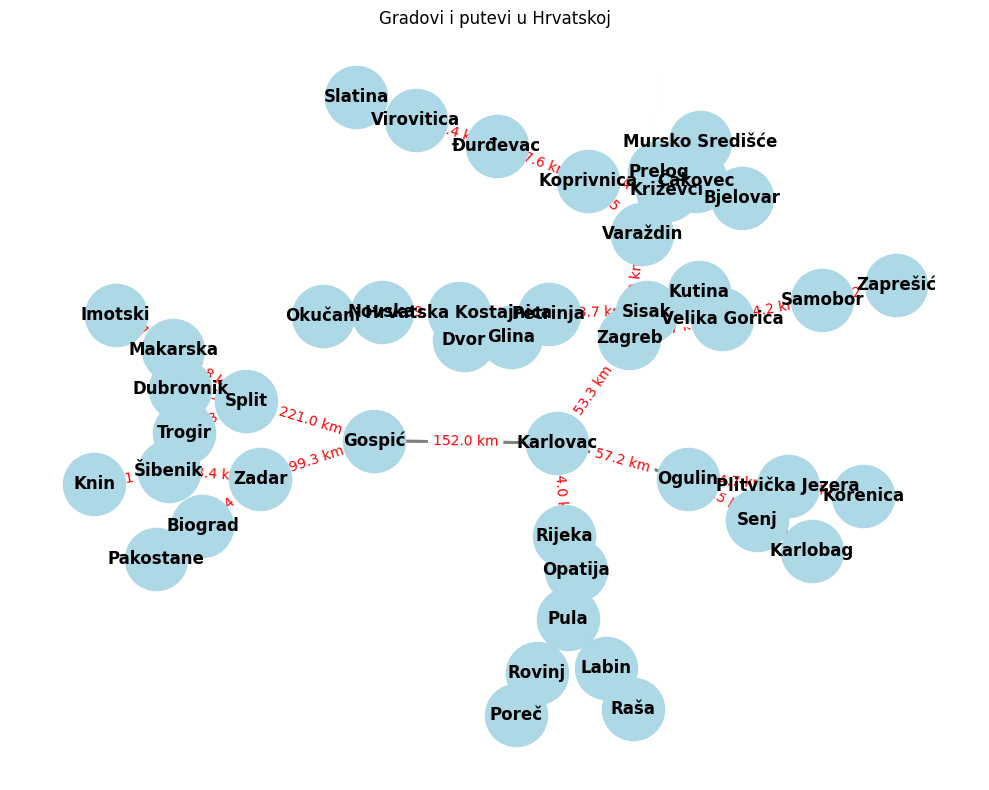

In [6]:
draw_graph(ceste)

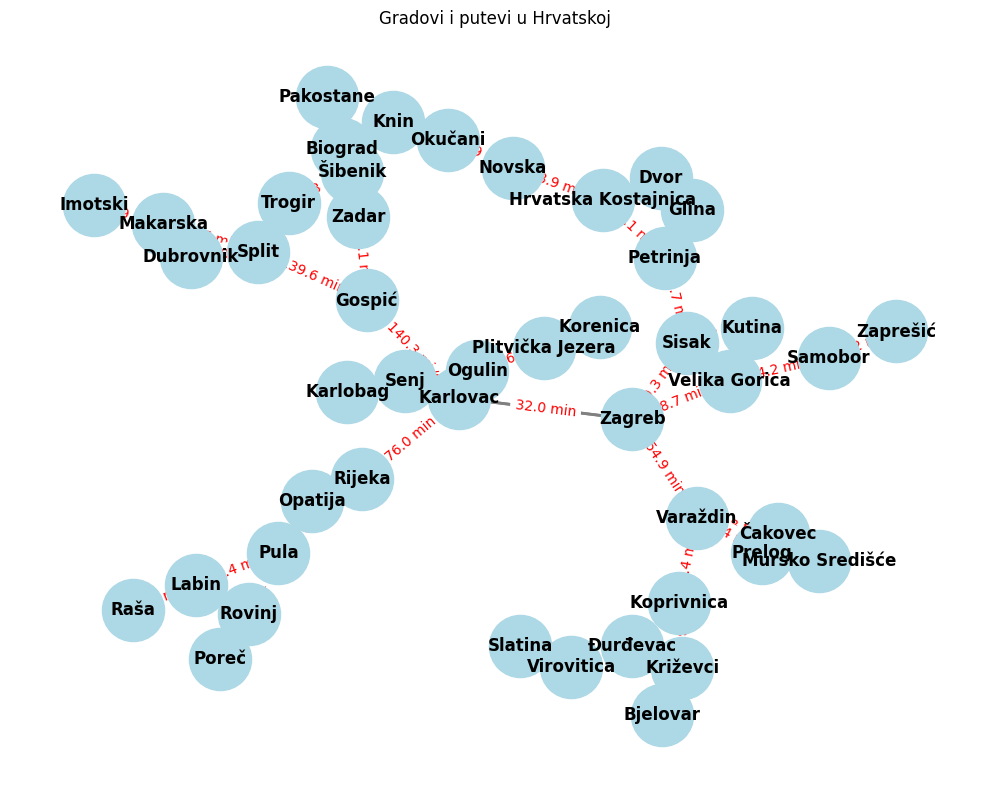

In [7]:
draw_graph(ceste, 'trajanje')

### 3. Implementirati funkcionalnost koja će za primjere proizvoljno zadanih polazišta i odredišta izračunati najkraće putove između njih (dokumentirati najmanje četiri proizvoljna primjera), i s obzirom na udaljenost u [km] i s obzirom na trajanje putovanja u [min]. U oba slučaja pored vrijednosti najkraćeg puta dati i redoslijed svih čvorova na tom putu. Može se koristiti postojeći Python kôd za Dijkstra algoritam, dati rješenje u bilo kojem drugom jeziku ili uporabom NetworkX biblioteke.

In [12]:
ispisNajkracegPuta(ceste, 'Zagreb', 'Split')
ispisNajkracegPuta(ceste, 'Gospić', 'Knin')
ispisNajkracegPuta(ceste, 'Rijeka', 'Virovitica')
ispisNajkracegPuta(ceste, 'Petrinja', 'Imotski')

Najkraći put po udaljenosti (426.3 km): Zagreb -> Karlovac -> Gospić -> Split
Najkraći put po trajanju (311.9 min): Zagreb -> Karlovac -> Gospić -> Split
Najkraći put po udaljenosti (243.79999999999998 km): Gospić -> Zadar -> Šibenik -> Knin
Najkraći put po trajanju (203.9 min): Gospić -> Zadar -> Šibenik -> Knin
Najkraći put po udaljenosti (370.8 km): Rijeka -> Karlovac -> Zagreb -> Varaždin -> Koprivnica -> Đurđevac -> Virovitica
Najkraći put po trajanju (264.2 min): Rijeka -> Karlovac -> Zagreb -> Varaždin -> Koprivnica -> Đurđevac -> Virovitica
Najkraći put po udaljenosti (619.0 km): Petrinja -> Sisak -> Zagreb -> Karlovac -> Gospić -> Split -> Makarska -> Imotski
Najkraći put po trajanju (472.4 min): Petrinja -> Sisak -> Zagreb -> Karlovac -> Gospić -> Split -> Makarska -> Imotski


### 4. Izgraditi netežinsku inačicu grafa ove cestovne mreže kao primjera povezanosti vrhova te temeljem toga: a). Odrediti dijametar grafa, gustoću grafa i stupnjeve svih čvorova. b). Odrediti mjere centralnosti (one četiri koje su spomenute u materijalima s predavanja) svih vrhova grafa. 

In [9]:
graph = Graph(netezinskaInacica(ceste))

### a)

In [10]:
print("Dijametar:" ,graph.diameter())
print("Gustoća: ", graph.density())
print("Stupnjevi: ")
l=[]
for ver in graph:
    l.append((ver, graph.vertex_degree(ver)))
l = sorted(l, key=lambda x: x[1], reverse=True)
for i in l:
    print(i[0], ": ", i[1])


Dijametar: 10
Gustoća:  0.04734299516908213
Stupnjevi: 
Zagreb :  4
Karlovac :  4
Sisak :  4
Varaždin :  4
Split :  4
Velika Gorica :  3
Rijeka :  3
Gospić :  3
Ogulin :  3
Petrinja :  3
Koprivnica :  3
Pula :  3
Zadar :  3
Hrvatska Kostajnica :  3
Šibenik :  3
Čakovec :  2
Glina :  2
Mursko Središće :  2
Križevci :  2
Đurđevac :  2
Rovinj :  2
Labin :  2
Biograd :  2
Makarska :  2
Trogir :  2
Samobor :  2
Senj :  2
Plitvička Jezera :  2
Dvor :  2
Novska :  2
Prelog :  2
Virovitica :  2
Kutina :  1
Opatija :  1
Dubrovnik :  1
Bjelovar :  1
Poreč :  1
Raša :  1
Knin :  1
Pakostane :  1
Imotski :  1
Zaprešić :  1
Karlobag :  1
Korenica :  1
Okučani :  1
Slatina :  1


### b)

In [11]:
centralnosti(netezinskaInacica(ceste))

Degree Centrality: {'Zagreb': 0.08888888888888889, 'Karlovac': 0.08888888888888889, 'Sisak': 0.08888888888888889, 'Varaždin': 0.08888888888888889, 'Velika Gorica': 0.06666666666666667, 'Rijeka': 0.06666666666666667, 'Gospić': 0.06666666666666667, 'Ogulin': 0.06666666666666667, 'Petrinja': 0.06666666666666667, 'Kutina': 0.022222222222222223, 'Čakovec': 0.044444444444444446, 'Koprivnica': 0.06666666666666667, 'Pula': 0.06666666666666667, 'Opatija': 0.022222222222222223, 'Zadar': 0.06666666666666667, 'Split': 0.08888888888888889, 'Glina': 0.044444444444444446, 'Hrvatska Kostajnica': 0.06666666666666667, 'Mursko Središće': 0.044444444444444446, 'Križevci': 0.044444444444444446, 'Đurđevac': 0.044444444444444446, 'Rovinj': 0.044444444444444446, 'Labin': 0.044444444444444446, 'Šibenik': 0.06666666666666667, 'Biograd': 0.044444444444444446, 'Makarska': 0.044444444444444446, 'Dubrovnik': 0.022222222222222223, 'Trogir': 0.044444444444444446, 'Samobor': 0.044444444444444446, 'Senj': 0.04444444444